<a href="https://colab.research.google.com/github/gvp2ms/A03-knn/blob/main/a03_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tiffany Kim

**Date:** 10/02/2026

In [3]:
# Your Phase 1 solution to the problem goes here.


**What is the difference between regression and classification?**

Regression predicts continuous numerical values or outputs, while classification predicts discrete values or categories.

**What is a confusion table? What does it help us understand about a model's performance?**

A confusion table helps visualize the performance on a specific task of a person or algorithm. Each column represents predicted instances, while the rows reprensent actual instances. It helps understand a model's performance by breaking the instances of errors down into specific types, so you can see where a model fails and why it fails at a task, instead of generalizing the number of errors there were.

**What does the SSE quantify about a particular model?**

SSE is the Sum of Squared Errors, which quantifies the total error in a regression model, so it measures the discrepencies betwen the data and a particular model.

**What are overfitting and underfitting?**

Underfitting is when a model is too simple to capture the underlying patterns in the data. Overfitting is when a model not only captures the underlying patterns but also extraneous things like noise or random quirks. Both can cause the model to perform badly; underfitting performs badly on training data, and overfitting has high accuracy on training data but fails on validation.

**Why does splitting the data into training and testing sets, and choosing  k  by evaluating accuracy or SSE on the test set, improve model performance?**

Splitting the data into training and testing sets improves model performance by measuring generalization. The training sets learn the patterns by using a general amount of the data, while the testing sets evaluates how the learned model handles new, smaller, more specific sections of data. It also prevents the model from "memorizing" the data and makes it actually learn. Choosing k by evaluating accurancy or SSE on the test set also helps overfitting. Too small of a k means the model is overfitting, while too big of a k means the model is underfitting.

**With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Reporting a class label as a prediction means each input is classified as one specific category of output. This can be helpful because it is direct, simplistic, and requires lower storage and computing power. However, it can result in loss of information because the model has no uncertainty, and it can lead to false positives and negatives.

Reporting a probability distribution over class labels means a likelihood score is assigned to all possible classes, so that all the classes add up to 1. This helps reveal how sure a model is, the decision threshold can be changed, and allows you to combine predictions from multiple models. However, it is more complex to implement and can be less intuitive.

In [4]:
#Phase 1 Coding
import pandas as pd
import numpy as np

#1. Load the data. Perform some EDA, summarizing the target label and the features.
df = pd.read_csv('land_mines.csv')
print(df.columns)
print(df.isnull().sum())
print(df.describe())
#target label is mine type
print(df.mine_type.value_counts())
print(df.mine_type.value_counts(normalize=True))


Index(['voltage', 'height', 'soil', 'mine_type'], dtype='object')
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


In [5]:
#2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
x = df.drop(columns=['mine_type'])
y = df.mine_type
print(x.shape)
print(y.shape)
print(y.value_counts())
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42, stratify=y)
print("Training:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("Testing:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

#need to standardize variables ranges so that certain variables don't dominate the distance calculation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)


(338, 3)
(338,)
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Training:
mine_type
1    35
2    35
3    33
5    33
4    33
Name: count, dtype: int64
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64
Testing:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


In [6]:
#3 Build a  k -NN classifier. Explain how you select  k
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(y_pred)
print(y_test.values)

from sklearn.model_selection import cross_val_score
k_values = range(1, 21)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print("Optimal k:", optimal_k)

knn_final = KNeighborsClassifier(n_neighbors=optimal_k)

knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

#I chose my K as 6 by finding the value that had the highest cross-validation accuracy
#The cv_scores were my cross-validation so I chose the highest value of that list
#A k too small could make the model too sensitive to individual observations, causing overfitting
#A k too large could result in underfit and ignore meaningful data
#So, a k of 6 was the best choice


[1 4 3 1 1 5 3 1 4 2 2 5 3 4 4 1 2 5 2 1 3 2 4 2 1 2 3 3 1 1 4 2 1 2 2 5 3
 1 2 1 4 1 1 1 4 1 2 2 1 4 2 1 1 1 1 1 4 3 5 4 5 3 4 1 2 4 2 4 1 4 2 3 2 5
 3 2 4 5 1 4 4 3 1 3 1 4 1 3 1 1 2 5 2 2 2 2 1 3 2 1 2 1 5 1 5 2 3 4 2 1 1
 1 2 3 5 3 4 2 4 3 2 1 2 3 5 5 1 5 2 2 1 1 4 3 1 1 3 3 4 4 1 4 5 4 1 1 3 1
 2 2 3 5 4 1 1 5 5 4 1 2 1 1 3 1 2 2 2 1 3]
[3 1 4 4 3 3 4 4 2 4 2 5 1 3 5 4 2 5 2 1 1 2 3 2 1 2 5 3 4 1 5 2 1 2 2 3 4
 1 2 5 5 1 4 3 4 1 2 2 1 1 3 3 5 4 1 1 5 1 2 3 3 3 3 1 2 5 2 5 5 4 2 1 2 4
 5 2 4 5 1 4 3 5 5 5 1 5 3 5 1 1 4 5 2 4 2 2 4 5 2 5 3 4 1 4 4 2 1 3 2 5 3
 1 2 1 3 4 4 2 5 3 2 1 2 4 3 3 4 3 2 4 1 1 5 5 1 1 4 5 2 3 1 3 3 5 1 4 3 4
 2 4 4 4 5 3 1 3 3 1 4 2 3 1 5 1 2 2 3 5 5]
Optimal k: 6


Confusion Matrix:
[[23  0  7  5  1]
 [ 0 34  0  1  0]
 [ 9  3  5  6 10]
 [15  5  7  3  3]
 [ 9  2 10  6  5]]


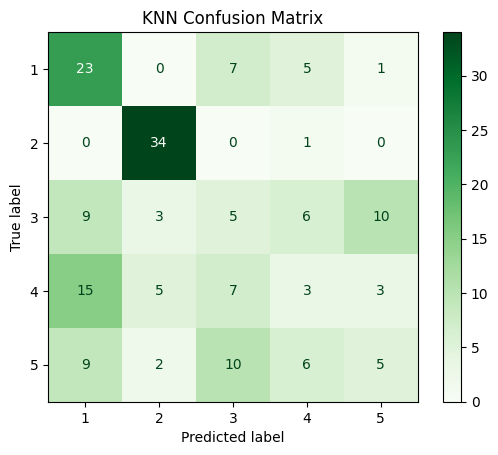

Test-set accuracy: 0.41420118343195267

Classification report:
              precision    recall  f1-score   support

           1       0.41      0.64      0.50        36
           2       0.77      0.97      0.86        35
           3       0.17      0.15      0.16        33
           4       0.14      0.09      0.11        33
           5       0.26      0.16      0.20        32

    accuracy                           0.41       169
   macro avg       0.35      0.40      0.37       169
weighted avg       0.36      0.41      0.38       169


Based on the classification report, the model has 41% overall accuracy
Mine type 2 is where the model performed the best, with a precision of 77% and a recall of 91%.
Mine types 3, 4, and 5 are where the model performed poorly. The precision is between 14-26% and the recall is between 9-16%.


In [7]:
#4 Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred,labels=[1, 2, 3, 4, 5])
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])

disp.plot(cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.show()

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Test-set accuracy:", accuracy)
print("\nClassification report:")
print(classification_report(y_test, y_pred, labels=[1, 2, 3, 4, 5],zero_division=0))
print()
print("Based on the classification report, the model has 41% overall accuracy")
print("Mine type 2 is where the model performed the best, with a precision of 77% and a recall of 91%.")
print("Mine types 3, 4, and 5 are where the model performed poorly. The precision is between 14-26% and the recall is between 9-16%.")


**Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.**

I would not advise the use of a K-NN model as an autonomous system to decide if a suspected landmine is safe or not. Instead, the predictions drawn from the model can be assessed by a human as a preliminary screening or decision making tool. The overall accuracy of the model is misleading because it can only precisely detect one type of mine. This model can be used to give an initial view of types of mines, but specific detection of mines should be consulted by a human.



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [9]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]